<center>
    <h2 style="color:blue;">ISAT 341: Machine Learning and Data Science
</h2>
<h3 style="color:green;">Final Project: Image Classification with Scikit-Learn 
</h3>
    
</center>
    <h5 style="color:orange;">Emily Waters and Livi Barker
    </h5>
</center>

<h3>Objectives</h3>
Build and evaluate an image classification model in Python using
Scikit-Learn inside Anaconda/Jupyter Notebook.

The main focus is on:
<ul>
    <li>loading and exploring an image or image-like dataset,
</li>
    <li>training one Scikit-Learn classification model,
</li>
    <li>evaluating the model with standard classification metrics,
</li>
    <li>explaining the results clearly.</li>
</ul>

<h3 style="color:green;">Task 1: Load and Explore the Dataset
</h3>

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np
# default dataset
digits = load_digits()

X = digits.data # Flattened image data: one row per image
y = digits.target # Correct labels
images = digits.images # 8 by 8 image arrays


print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", digits.target_names)


Feature matrix shape: (1797, 64)
Target shape: (1797,)
Class names: [0 1 2 3 4 5 6 7 8 9]


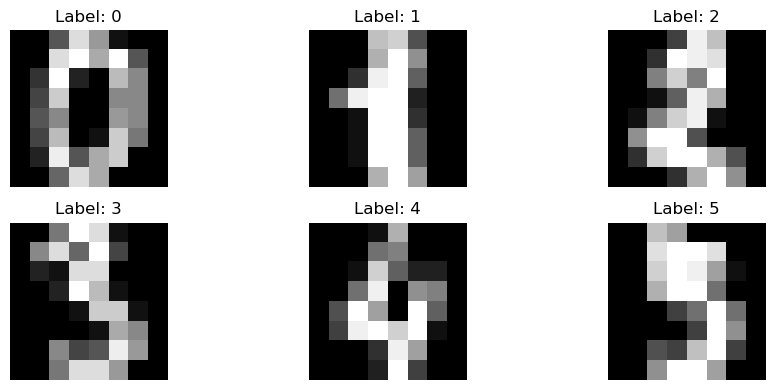

In [2]:
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

<h3 style="color:green;">Task 2: Split the Data and Train One Model</h3>
Split the data into training and testing sets. Then choose one Scikit-Learn classification algorithm
and train it.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the data
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

# knn = 10
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train_std, y_train)
y_pred = knn.predict(X_test_std)
accuracy = knn.score(X_test_std, y_test)
print("======================")
print('KNN model with k =', 10)
print('Accuracy:', accuracy)
print()

KNN model with k = 10
Accuracy: 0.9611111111111111



<h3 style="color:green;">Task 3: Evaluate the Model
</h3>
Make predictions on the test set. Then report the accuracy, classification report, and confusion
matrix.

Accuracy: 0.9611111111111111
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      1.00      0.95        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      0.97      0.97        36
           7       0.92      0.97      0.95        36
           8       0.97      0.86      0.91        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



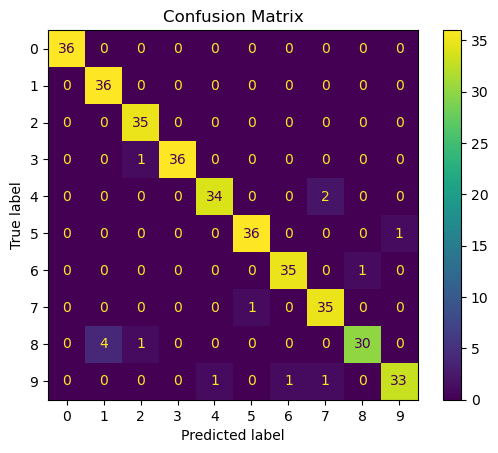

In [7]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
# Make predictions
y_pred = knn.predict(X_test_std)
# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

<h3 style="color:green;">Task 4: Show Prediction Examples
</h3>
Display at least 6 test images or examples with their predicted labels and actual labels.


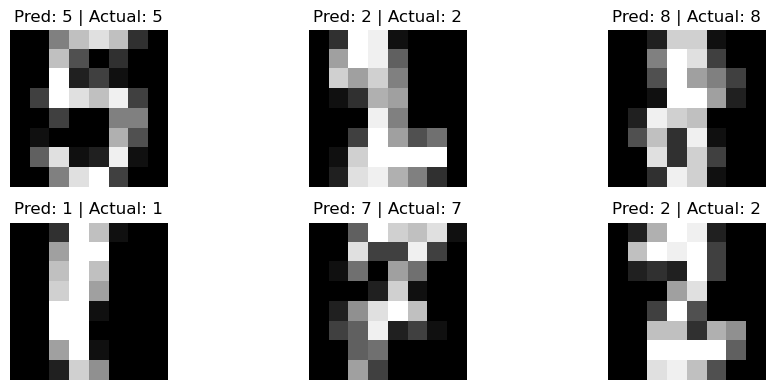

In [5]:
plt.figure(figsize=(10, 4))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
    plt.title(f"Pred: {y_pred[i]} | Actual: {y_test[i]}")
    plt.axis("off")
plt.tight_layout()

plt.show()

<h3 style="color:green;">Task 5: Short Reflection
</h3>
Write one short paragraph answering the following:
<br>
• Which dataset and algorithm did YOU use?
<br>
• What was the accuracy?
<br>
• Based on the confusion matrix, where did the model do well or make mistakes?
<br>
• Overall, did the model perform well? Explain briefly.

For this project, we used the digits dataset from Scikit-Learn and applied a K-Nearest Neighbors (KNN) classification algorithm with k = 10. After splitting the data and scaling the features, our model achieved an accuracy of 96% on the test set. Based on the confusion matrix, the model performed very well on most digits, especially those with clear and distinct shapes such as 0, 1, and 6. However, it made some mistakes when classifying digits such as 4, 8, and 9. Overall, the model performed well and demonstrated high accuracy, showing that KNN is effective for this type of image classification task.